In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/darlingloya13/zudio-stores2/filtered1.csv
/kaggle/input/datasets/darlingloya13/zudio-stores2/result with already store.csv
/kaggle/input/datasets/darlingloya13/zudio-stores2/result with no store.csv
/kaggle/input/datasets/darlingloya13/zudio-stores2/store.csv


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames:
        print("   ", filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/darlingloya13
/kaggle/input/datasets/darlingloya13/zudio-stores2
    filtered1.csv
    result with already store.csv
    result with no store.csv
    store.csv


In [3]:
import pandas as pd

store = pd.read_csv(
    "/kaggle/input/datasets/darlingloya13/zudio-stores2/store.csv"
)

store.head()

,Unnamed: 0,Store Name,State,City,Address,Estimated Population,Per Capita Income,Malls,buyers count,potential location
0,0,"Zudio - VRK One, Adoni",Andhra Pradesh,Adoni,"Plot No 90 & 91, Ground Floor & First Floor, B...",261000,219518,1,130500.0,0.2
1,1,"Zudio - Rudrampeta, Anantapur",Andhra Pradesh,Anantapur,"Near SUNRAY SVR Hospital, Rudrampeta, Kalyanad...",498089,219518,1,249044.5,53.6
2,2,"Zudio - Court Road, Anantapur",Andhra Pradesh,Anantapur,"Adimurthy Nagar, Court Road, Gulzarpet, Ananta...",498089,219518,1,249044.5,53.6
3,3,"ZUDIO - Chirala, Andhra Pradesh",Andhra Pradesh,Chirala,"Chirala Main Road, Near Vishal Mega Mart, Near...",229000,219518,1,114500.0,0.2
4,4,"ZUDIO - Tirupathi Road, Chittoor",Andhra Pradesh,Chittoor,"22-270, 271, Tirupati Road, Chittoor - 517001",248000,219518,1,124000.0,0.2


In [4]:
len(store)

968

In [5]:
store_info = store['State'].value_counts()
print(store_info)

State
Maharashtra          136
Karnataka             88
Gujarat               86
Uttar Pradesh         80
Telangana             77
Kerala                65
West Bengal           46
Punjab                45
Delhi                 44
Tamil Nadu            43
Rajasthan             41
Andhra Pradesh        38
Haryana               35
Madhya Pradesh        28
Odisha                20
Assam                 20
Bihar                 20
Chhattisgarh          13
Uttarakhand           10
Jharkhand              7
Goa                    7
Himachal Pradesh       3
Sikkim                 3
Nagaland               3
Manipur                3
Arunachal Pradesh      2
Jammu&Kashmir          2
Puducherry             1
Meghalaya              1
Mizoram                1
Name: count, dtype: int64


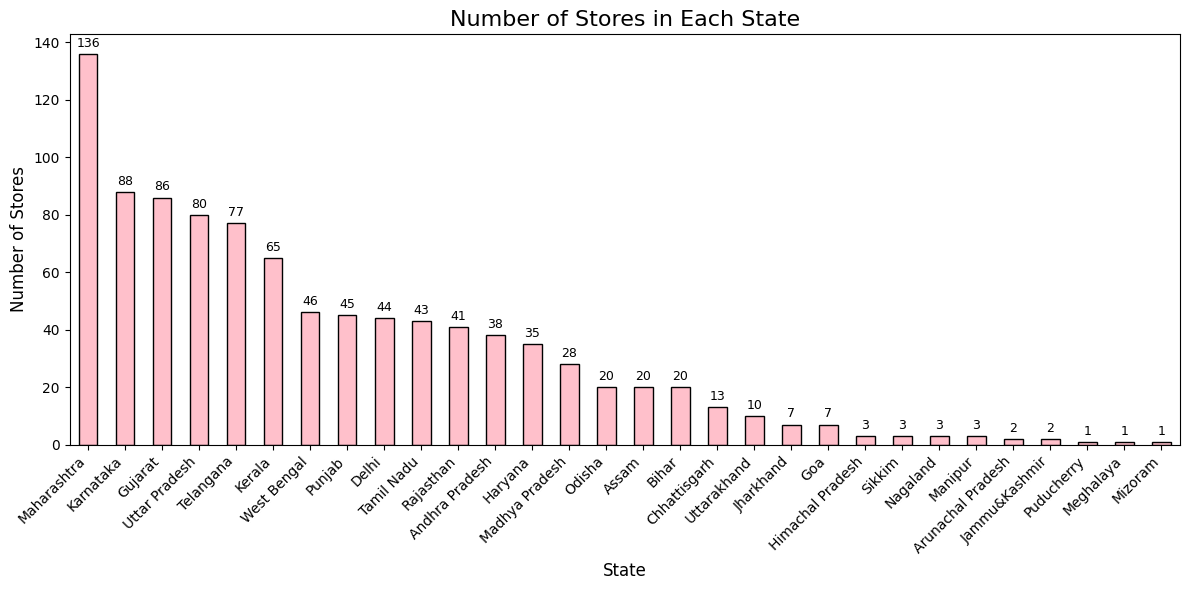

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

ax = store_info.plot(kind='bar', color='pink', edgecolor='black')

ax.bar_label(ax.containers[0], padding=3, fontsize=9)

plt.title('Number of Stores in Each State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Stores', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [7]:

count=store['City'].value_counts()
display(count)

City
Hyderabad      65
Bengaluru      62
Pune           39
Mumbai         33
New Delhi      28
               ..
Cooch Behar     1
Barrackpore     1
Guntakal        1
Eluru           1
Chittoor        1
Name: count, Length: 307, dtype: int64

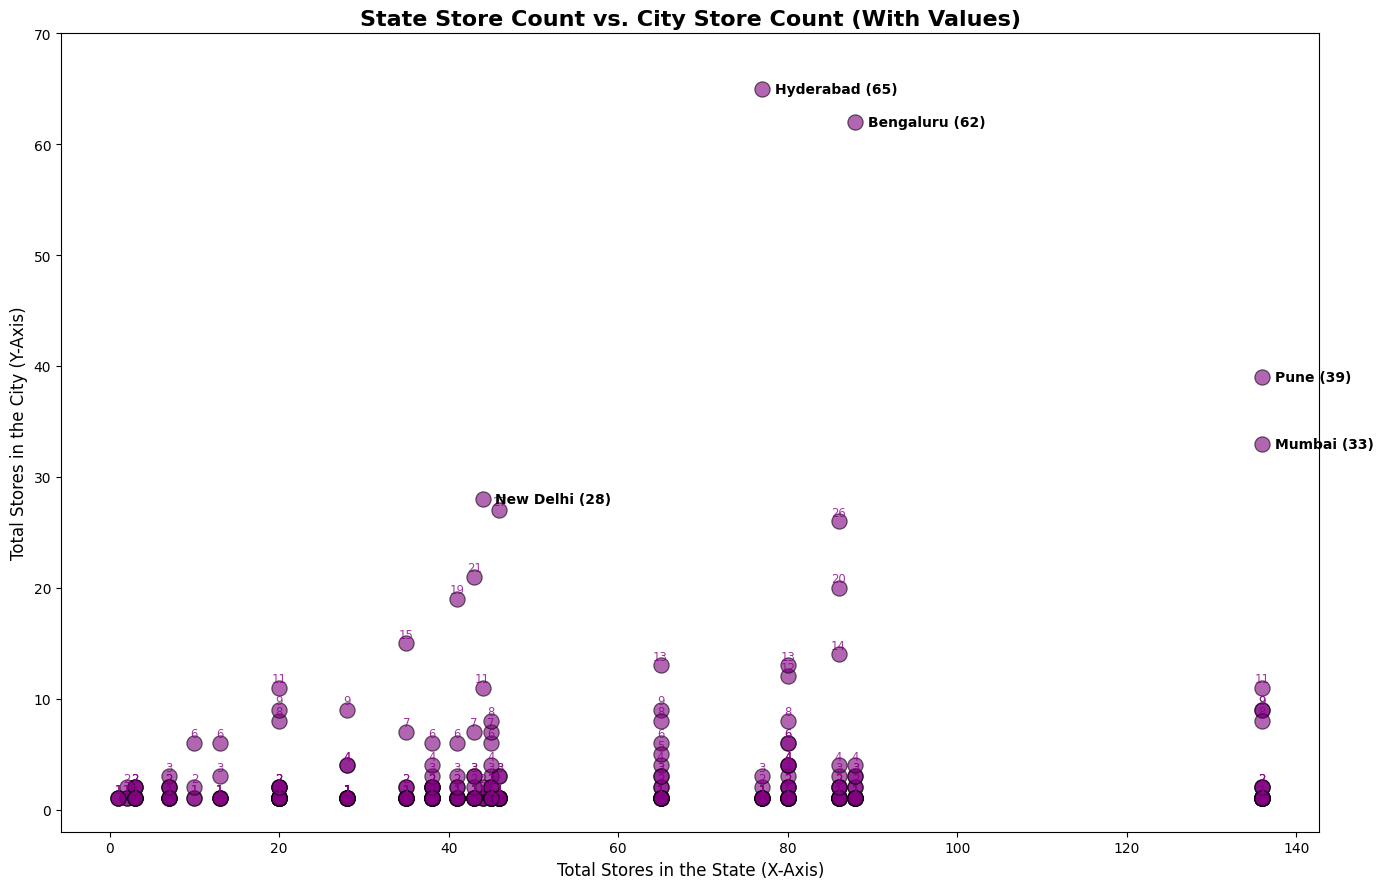

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map the state store counts back to each city in the original dataframe
store['State_Total'] = store['State'].map(store_info)

# 2. Group by City to get both the City Count and its State's Total Count
city_comparison = store.groupby('City').agg(
    City_Total=('City', 'count'),
    State_Total=('State_Total', 'first')
).reset_index()

# 3. Create the Scatter Plot
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=city_comparison,
    x='State_Total',
    y='City_Total',
    alpha=0.6,
    color='purple',
    s=120,
    edgecolor='black'
)

# 4. Loop through ALL points to add their number values (and names for top cities)
top_cities_to_label = ['Hyderabad', 'Bengaluru', 'Pune', 'Mumbai', 'New Delhi']

for line in range(0, city_comparison.shape[0]):
    x_val = city_comparison.iloc[line]['State_Total']
    y_val = city_comparison.iloc[line]['City_Total']
    city_name = city_comparison.iloc[line]['City']

    # Label top cities with "Name (Value)"
    if city_name in top_cities_to_label:
        plt.text(
            x_val + 1.5,
            y_val,
            f"{city_name} ({y_val})",
            horizontalalignment='left',
            verticalalignment='center',
            size='medium',
            color='black',
            weight='bold'
        )
    # For all other dense points, just put the small number value slightly above the dot
    else:
        plt.text(
            x_val,
            y_val + 0.5,
            str(y_val),
            horizontalalignment='center',
            size='small',
            color='darkmagenta',
            alpha=0.8
        )

plt.title('State Store Count vs. City Store Count (With Values)', fontsize=16, fontweight='bold')
plt.xlabel('Total Stores in the State (X-Axis)', fontsize=12)
plt.ylabel('Total Stores in the City (Y-Axis)', fontsize=12)
plt.ylim(-2, city_comparison['City_Total'].max() + 5) # Give some headroom for text labels
plt.tight_layout()
plt.show()

/tmp/ipykernel_16/1962275663.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


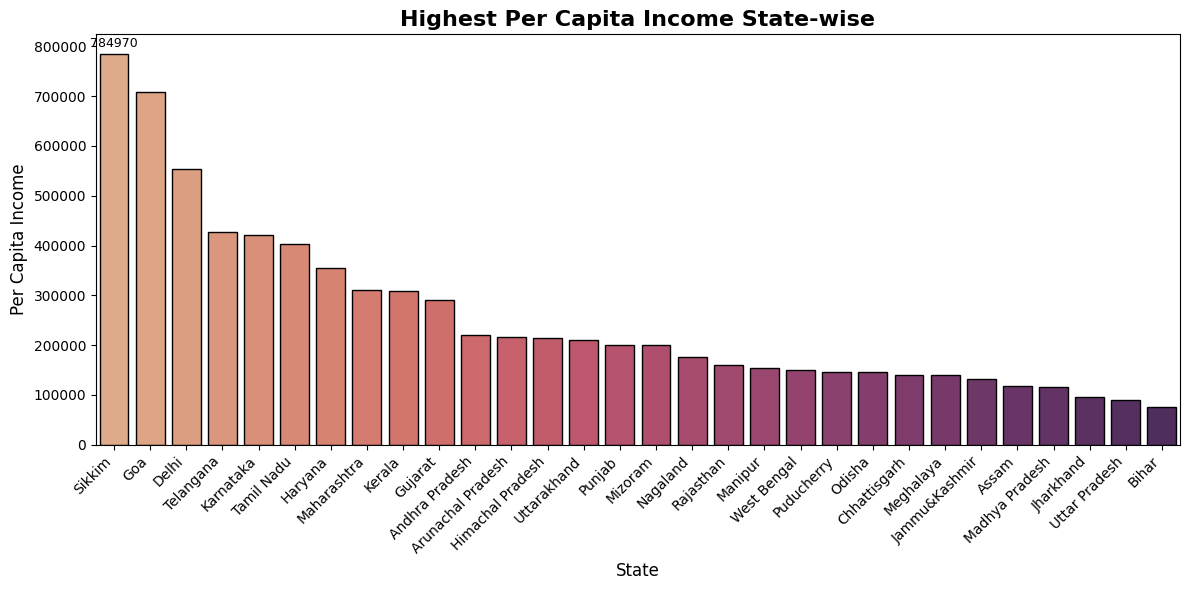

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean up income: Remove commas (if any) and convert to numeric
store['Per Capita Income'] = store['Per Capita Income'].astype(str).str.replace(',', '')
store['Per Capita Income'] = pd.to_numeric(store['Per Capita Income'], errors='coerce')

# 2. Group by State to find the highest (max) Per Capita Income per state
state_income = store.groupby('State')['Per Capita Income'].max().dropna().reset_index()

# 3. Sort states by income in descending order
state_income = state_income.sort_values(by='Per Capita Income', ascending=False)

# 4. Plot the graph
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=state_income,
    x='State',
    y='Per Capita Income',
    palette='flare',
    edgecolor='black'
)

# 5. Add values on top of the bars
ax.bar_label(ax.containers[0], padding=3, fmt='%.0f', fontsize=9)

# 6. Customize titles and labels
plt.title('Highest Per Capita Income State-wise', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Per Capita Income', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_16/125267201.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


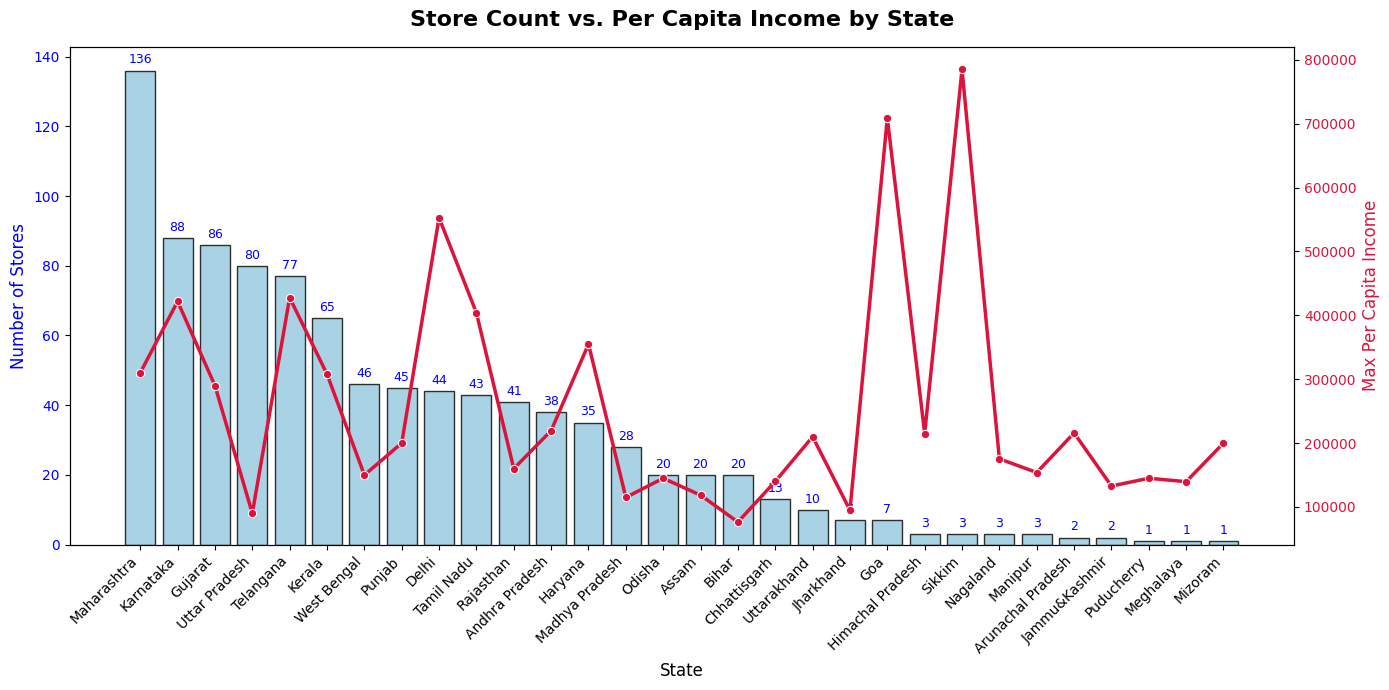

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean up income data in the main 'store' DataFrame
store['Per Capita Income'] = store['Per Capita Income'].astype(str).str.replace(',', '')
store['Per Capita Income'] = pd.to_numeric(store['Per Capita Income'], errors='coerce')

# 2. Calculate Store Count and Max Per Capita Income per State
state_stats = store.groupby('State').agg(
    Store_Count=('State', 'count'),
    Max_Income=('Per Capita Income', 'max')
).dropna().reset_index()

# Sort by store count descending for a cleaner layout
state_stats = state_stats.sort_values(by='Store_Count', ascending=False)

# 3. Initialize the plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# 4. Plot Store Counts as Bars (Left Axis)
sns.barplot(
    data=state_stats,
    x='State',
    y='Store_Count',
    ax=ax1,
    color='skyblue',
    edgecolor='black',
    alpha=0.8
)
ax1.set_title('Store Count vs. Per Capita Income by State', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('State', fontsize=12)
ax1.set_ylabel('Number of Stores', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Add counts on top of bars
ax1.bar_label(ax1.containers[0], padding=3, fontsize=9, color='blue')

# 5. Create a secondary Y-axis for Per Capita Income (Right Axis)
ax2 = ax1.twinx()
sns.lineplot(
    data=state_stats,
    x='State',
    y='Max_Income',
    ax=ax2,
    color='crimson',
    marker='o',
    linewidth=2.5,
    sort=False  # Keep alignment with sorted bar chart positions
)
ax2.set_ylabel('Max Per Capita Income', color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/darlingloya13/zudio-stores2/filtered1.csv",
    encoding="latin1"
)

df.head()

,Unnamed: 0,city,State,population,buyers count,Malls,potential location
0,0,Takkolu,Andhra Pradesh,3465,1732.5,0,79.0
1,1,SataÂnagaram,Andhra Pradesh,5447,2723.5,0,68.2
2,2,PaÂtacudapah,Andhra Pradesh,4730,2365.0,0,38.0
3,3,Guntar,Andhra Pradesh,670073,335036.5,1,44.0
4,4,PaÂtapaÂdu,Andhra Pradesh,3933,1966.5,0,59.8


In [12]:
# 1. Ensure the required columns are numeric and handle any missing values (NaNs)
df['population'] = pd.to_numeric(df['population'], errors='coerce').fillna(0)
df['buyers count'] = pd.to_numeric(df['buyers count'], errors='coerce').fillna(0)
df['Malls'] = pd.to_numeric(df['Malls'], errors='coerce').fillna(0)

# 2. Calculate the 'potential location' column with the modulo (%) 100 operation
df['potential location'] = ((0.4 * df['population']) + (0.4 * df['buyers count']) + (0.2 * df['Malls'])) % 100

# 3. Save the updated dataframe back to your CSV file
df.to_csv('filtered.csv', index=False)

# 4. View the updated data
df.head()

,Unnamed: 0,city,State,population,buyers count,Malls,potential location
0,0,Takkolu,Andhra Pradesh,3465,1732.5,0,79.0
1,1,SataÂnagaram,Andhra Pradesh,5447,2723.5,0,68.2
2,2,PaÂtacudapah,Andhra Pradesh,4730,2365.0,0,38.0
3,3,Guntar,Andhra Pradesh,670073,335036.5,1,44.0
4,4,PaÂtapaÂdu,Andhra Pradesh,3933,1966.5,0,59.8


/tmp/ipykernel_16/2027905432.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


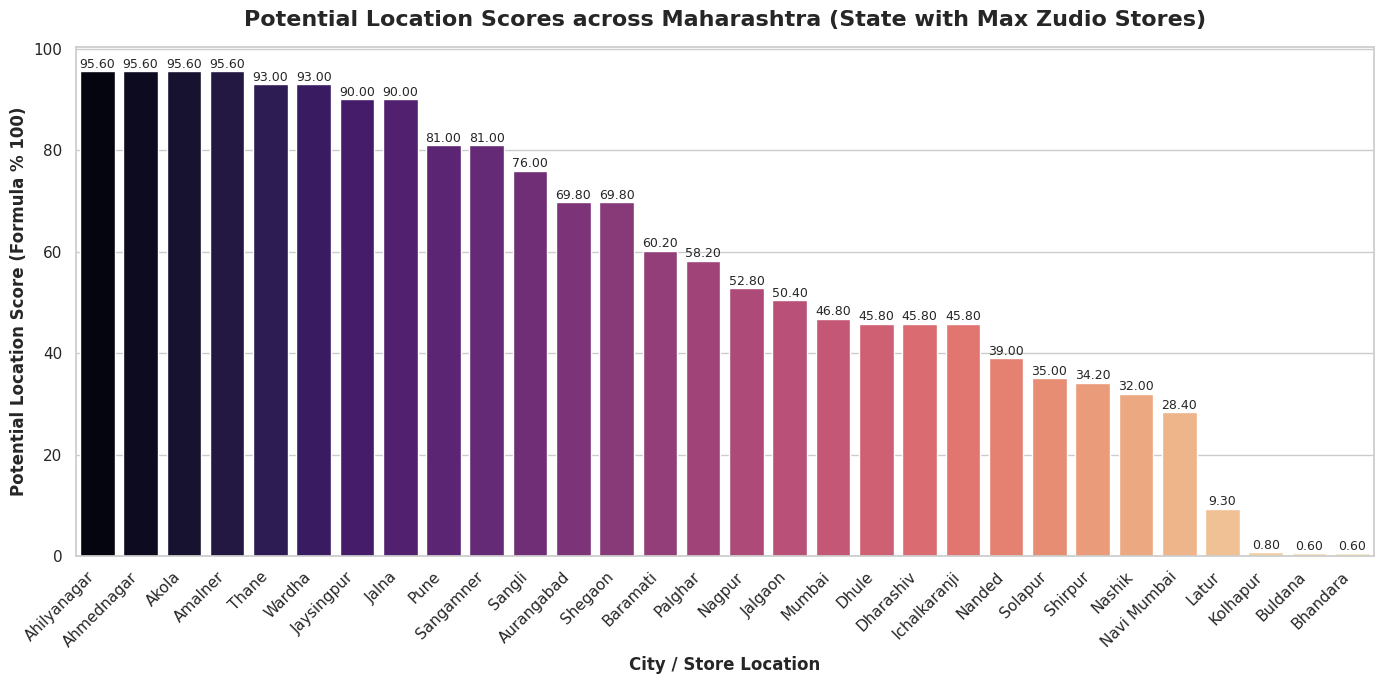

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your updated dataset
df = pd.read_csv('/kaggle/input/datasets/darlingloya13/zudio-stores2/store.csv', encoding='latin1')

# 2. Clean up the State column names
df['State'] = df['State'].astype(str).str.strip()

# 3. Dynamically find the state with the maximum number of stores
max_store_state = df['State'].value_counts().idxmax()

# 4. Filter data to include ONLY that specific state
state_df = df[df['State'] == max_store_state]

# 5. Group by City within that state to get the potential location score per city
# (Sorting them from highest score to lowest score)
city_scores = state_df.groupby('City')['potential location'].mean().reset_index()
city_scores = city_scores.sort_values(by='potential location', ascending=False)

# 6. Set up the plotting style
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 7. Create a bar plot for the cities in this state
ax = sns.barplot(
    x='City',
    y='potential location',
    data=city_scores,
    palette='magma'
)

# 8. Customize labels and title
plt.title(f'Potential Location Scores across {max_store_state} (State with Max Zudio Stores)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('City / Store Location', fontsize=12, fontweight='bold')
plt.ylabel('Potential Location Score (Formula % 100)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')  # Rotates city names so they don't overlap

# 9. Add value labels on top of each bar for easy reading
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=9)

# 10. Adjust layout and display the graph
plt.tight_layout()
plt.show()

/tmp/ipykernel_16/62398498.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


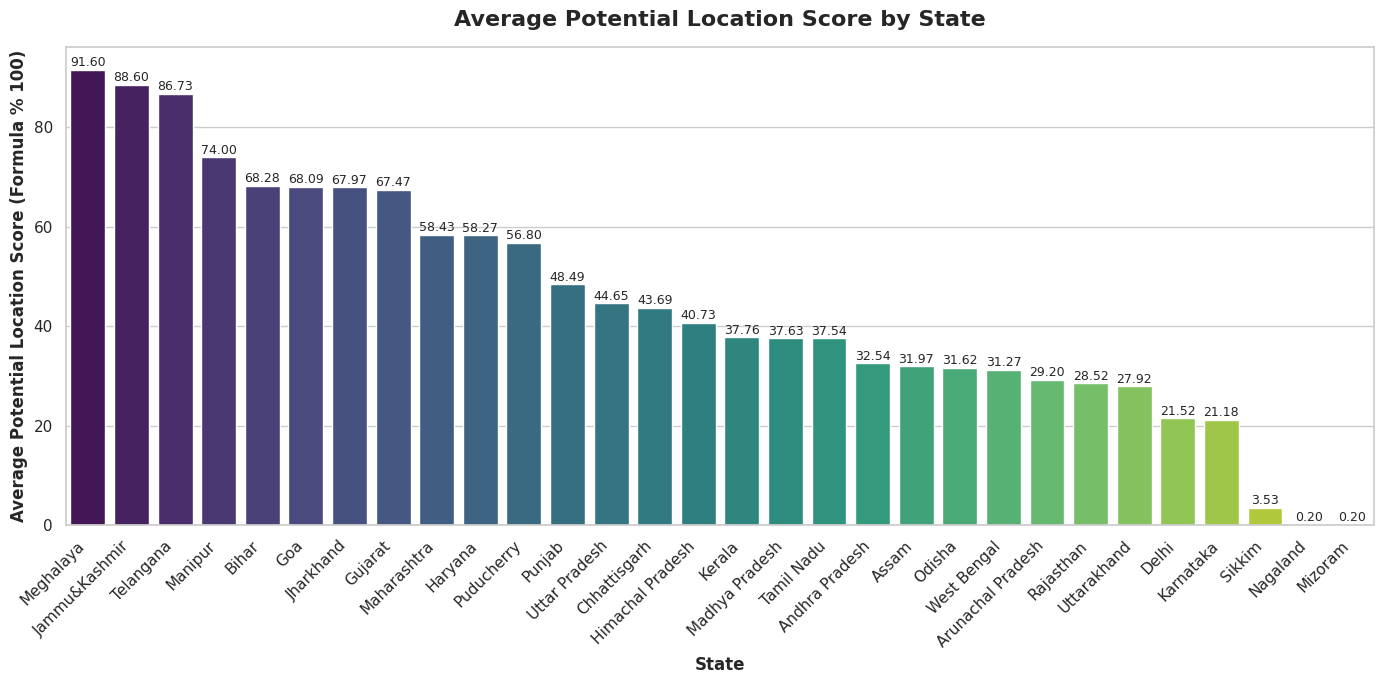

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your updated dataset
df = pd.read_csv('/kaggle/input/datasets/darlingloya13/zudio-stores2/store.csv', encoding='latin1')

# 2. Clean up the State column names (remove leading/trailing spaces)
df['State'] = df['State'].astype(str).str.strip()

# 3. Group by State, calculate the average potential location score, and sort
state_scores = df.groupby('State')['potential location'].mean().reset_index()
state_scores = state_scores.sort_values(by='potential location', ascending=False)

# 4. Set up the plotting style
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 5. Create the bar plot for all states
ax = sns.barplot(
    x='State',
    y='potential location',
    data=state_scores,
    palette='viridis'
)

# 6. Customize labels and title
plt.title('Average Potential Location Score by State', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('State', fontsize=12, fontweight='bold')
plt.ylabel('Average Potential Location Score (Formula % 100)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')  # Rotates state names so they don't overlap

# 7. Add value labels on top of each bar for easy reading
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=9)

# 8. Adjust layout and display the graph
plt.tight_layout()
plt.show()


/tmp/ipykernel_16/3444994684.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


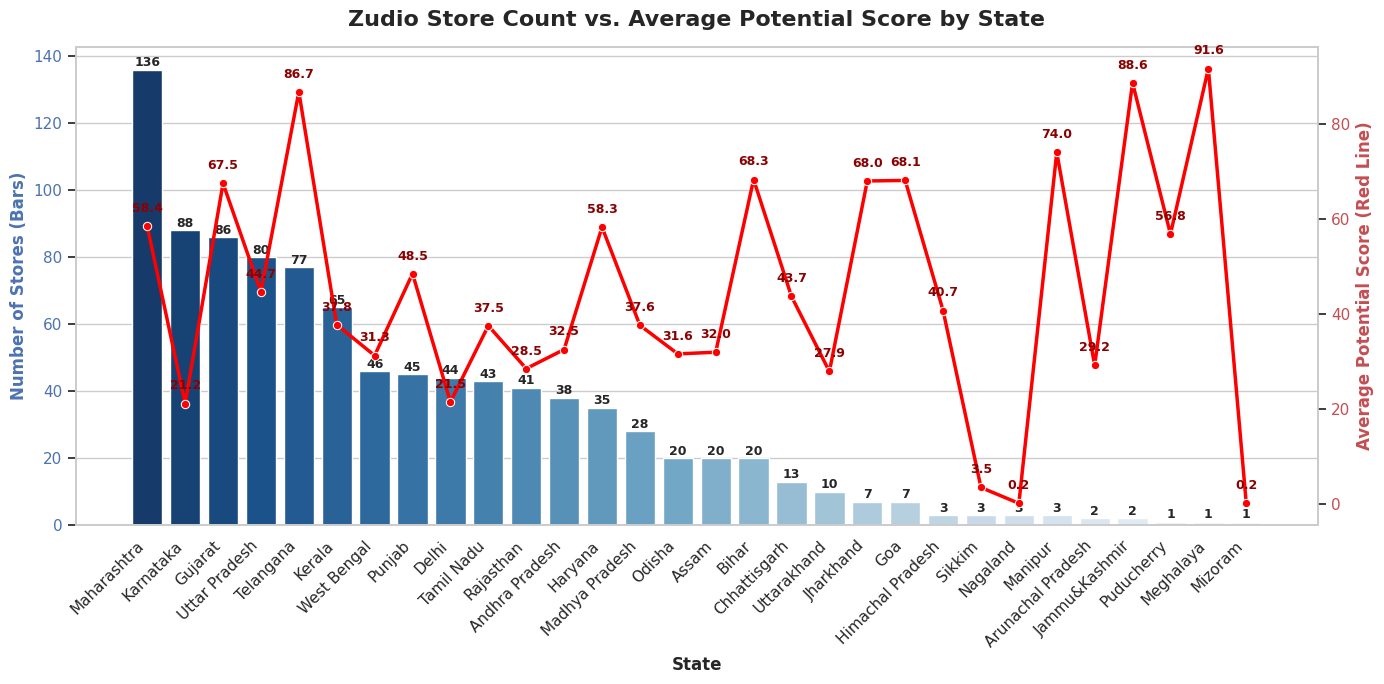

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('/kaggle/input/datasets/darlingloya13/zudio-stores2/store.csv', encoding='latin1')
df['State'] = df['State'].astype(str).str.strip()

# 2. Calculate both the store counts AND the average potential score per state
state_stats = df.groupby('State').agg(
    Store_Count=('State', 'count'),
    Avg_Potential_Score=('potential location', 'mean')
).reset_index()

# Sort by the number of stores so the biggest states are on the left
state_stats = state_stats.sort_values(by='Store_Count', ascending=False)

# 3. Set up the plot layout
fig, ax1 = plt.subplots(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 4. Draw the BARS for Store Count (Primary Y-Axis)
sns.barplot(
    x='State',
    y='Store_Count',
    data=state_stats,
    palette='Blues_r',
    ax=ax1
)
ax1.set_title('Zudio Store Count vs. Average Potential Score by State', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('State', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Stores (Bars)', fontsize=12, fontweight='bold', color='b')
ax1.tick_params(axis='y', labelcolor='b')
plt.xticks(rotation=45, ha='right')

# Add store count labels on top of the bars
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

# 5. Create a secondary Y-axis for the potential score
ax2 = ax1.twinx()

# 6. Draw the LINE for Potential Score (Secondary Y-Axis)
sns.lineplot(
    x='State',
    y='Avg_Potential_Score',
    data=state_stats,
    color='red',
    marker='o',
    linewidth=2.5,
    ax=ax2
)
ax2.set_ylabel('Average Potential Score (Red Line)', fontsize=12, fontweight='bold', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.grid(False) # Turn off overlapping grid lines

# Add the potential score labels above the line markers
for i, txt in enumerate(state_stats['Avg_Potential_Score']):
    ax2.annotate(f"{txt:.1f}",
                (i, state_stats['Avg_Potential_Score'].iloc[i]),
                ha='center', va='bottom', xytext=(0, 8), textcoords='offset points',
                fontsize=9, color='darkred', fontweight='bold')

# 7. Final display adjustments
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

# 1. Load your updated dataset
df = pd.read_csv('/kaggle/input/datasets/darlingloya13/zudio-stores2/store.csv', encoding='latin1')
df['State'] = df['State'].astype(str).str.strip()

# 2. Pre-calculate the Store Count per State and map it back to each row
state_counts = df['State'].value_counts()
df['state_store_count'] = df['State'].map(state_counts)

# 3. Apply Min-Max Normalization for Potential Location
# Formula: (x - min) / (max - min)
min_score = df['potential location'].min()
max_score = df['potential location'].max()

# Check to avoid division by zero if all scores are identical
if max_score != min_score:
    df['Norm_Potential'] = (df['potential location'] - min_score) / (max_score - min_score)
else:
    df['Norm_Potential'] = 0.0

# 4. Apply Min-Max Normalization for Store Counts
min_stores = df['state_store_count'].min()
max_stores = df['state_store_count'].max()

if max_stores != min_stores:
    df['Norm_Stores'] = (df['state_store_count'] - min_stores) / (max_stores - min_stores)
else:
    df['Norm_Stores'] = 0.0

# 5. Drop the temporary count column and save the file
df = df.drop(columns=['state_store_count'])
df.to_csv('store1_normalized.csv', index=False)

# 6. View the new columns
df[['State', 'City', 'potential location', 'Norm_Potential', 'Norm_Stores']].head()

,State,City,potential location,Norm_Potential,Norm_Stores
0,Andhra Pradesh,Adoni,0.2,0.002012,0.274074
1,Andhra Pradesh,Anantapur,53.6,0.539235,0.274074
2,Andhra Pradesh,Anantapur,53.6,0.539235,0.274074
3,Andhra Pradesh,Chirala,0.2,0.002012,0.274074
4,Andhra Pradesh,Chittoor,0.2,0.002012,0.274074


In [17]:
import pandas as pd

# 1. Load the filtered dataset
df = pd.read_csv('/kaggle/input/datasets/darlingloya13/zudio-stores2/filtered1.csv', encoding='latin1')
df['State'] = df['State'].astype(str).str.strip()

# 2. Count the store distribution per state and map it back to the rows
state_counts = df['State'].value_counts()
df['state_store_count'] = df['State'].map(state_counts)

# 3. Apply Min-Max Normalization for the 'potential location' score
min_score = df['potential location'].min()
max_score = df['potential location'].max()

if max_score != min_score:
    df['Norm_Potential'] = (df['potential location'] - min_score) / (max_score - min_score)
else:
    df['Norm_Potential'] = 0.0

# 4. Apply Min-Max Normalization for the store counts
min_stores = df['state_store_count'].min()
max_stores = df['state_store_count'].max()

if max_stores != min_stores:
    df['Norm_Stores'] = (df['state_store_count'] - min_stores) / (max_stores - min_stores)
else:
    df['Norm_Stores'] = 0.0

# 5. Calculate the final Priority Index column
df['Priority Index'] = df['Norm_Potential'] - df['Norm_Stores']

# 6. Clean up the temporary column and save back to the filtered CSV file
df = df.drop(columns=['state_store_count'])
df.to_csv('filtered.csv', index=False)

# 7. View your newly added tracking metrics
df[['State', 'city', 'potential location', 'Norm_Potential', 'Norm_Stores', 'Priority Index']].head()

,State,city,potential location,Norm_Potential,Norm_Stores,Priority Index
0,Andhra Pradesh,Takkolu,79.0,0.796371,0.107143,0.689228
1,Andhra Pradesh,SataÂnagaram,68.2,0.687500,0.107143,0.580357
2,Andhra Pradesh,PaÂtacudapah,38.0,0.383065,0.107143,0.275922
3,Andhra Pradesh,Guntar,44.0,0.443548,0.107143,0.336406
4,Andhra Pradesh,PaÂtapaÂdu,59.8,0.602823,0.107143,0.495680


In [18]:
# Filter rows where the potential location score is >= 0.5
high_priority_locations = df[df['Priority Index'] >= 0.5]

# Display the filtered dataframe
high_priority_locations.head()

,Unnamed: 0,city,State,population,buyers count,Malls,potential location,Norm_Potential,Norm_Stores,Priority Index
0,0,Takkolu,Andhra Pradesh,3465,1732.5,0,79.0,0.796371,0.107143,0.689228
1,1,SataÂnagaram,Andhra Pradesh,5447,2723.5,0,68.2,0.687500,0.107143,0.580357
5,5,Putlampalle,Andhra Pradesh,4490,2245.0,0,94.0,0.947581,0.107143,0.840438
6,6,AmbaÂpuram,Andhra Pradesh,4110,2055.0,0,66.0,0.665323,0.107143,0.558180
66,66,Chandigarh,Chandigarh,1026459,513229.5,1,75.6,0.762097,0.053571,0.708525
